**1. Import Libraries**

In [15]:
import torch
import torch.nn as nn
from torchvision.models import convnext_tiny
import onnxruntime as ort
from PIL import Image
from torchvision.models import ConvNeXt_Tiny_Weights
from torchvision import transforms
import numpy as np
import torch.nn.functional as F
from google.colab import files
import onnx
import matplotlib.pyplot as plt

**2. Upload the Weights of the Py.torch model**

In [5]:
# upload the convnext weights
uploaded = files.upload()

Saving Convnext_Best_AllDataset(0.660).pt to Convnext_Best_AllDataset(0.660).pt


**3. Recreate the Model from the Saved Weights**

In [34]:
# ---------------------------------------------------
# Recreate the model architecture
# We rebuild the same ConvNeXt model structure
# that was used during training.
# ---------------------------------------------------
NUM_CLASSES = 5

model_PyTorch = convnext_tiny(weights=None)

in_features = model_PyTorch .classifier[2].in_features
model_PyTorch.classifier[2] = nn.Sequential(
    nn.Dropout(0.05),
    nn.Linear(in_features, NUM_CLASSES)
)
# ---------------------------------------------------
# Load the trained weights from the .pt file
# This restores the learned parameters of the model.
# ---------------------------------------------------

state_dict = torch.load("Convnext_Best_AllDataset(0.660).pt", map_location="cpu")
model_PyTorch.load_state_dict(state_dict)

# ---------------------------------------------------
# Set the model to evaluation mode
# This disables training behaviors like dropout
# and ensures correct inference behavior.
# ---------------------------------------------------
model_PyTorch.eval()
print("Model loaded successfully")

Model loaded successfully


**4. Create a dummy tensor**

In [35]:
# ---------------------------------------------------
# Create a dummy input tensor
# ONNX export requires an example input to trace
# the computation graph of the model.
#
# Shape explanation:
# (batch_size, channels, height, width)
# ConvNeXt expects 224x224 RGB images.
# ---------------------------------------------------
dummy_input = torch.randn(1, 3, 224, 224)

**5. Convert to ONNX Format and Export the File**

In [36]:
# ---------------------------------------------------
# Export the PyTorch model to ONNX format
# This converts the computation graph and weights
# into a framework-independent format.
# ---------------------------------------------------
torch.onnx.export(
    model_PyTorch,
    dummy_input,
    "bouh_convnext_classifier_model.onnx",
    input_names=["image"],
    output_names=["logits"],

    # ------------------------------------------------
    # dynamic_axes allows variable batch sizes
    # This is required for dynamic batching
    # when using inference servers.
    # ------------------------------------------------
    dynamic_axes={
        "image": {0: "batch_size"},
        "logits": {0: "batch_size"}
    },

    opset_version=13,
    do_constant_folding=True,
    dynamo=False
    )

print("ONNX model exported successfully")

files.download("bouh_convnext_classifier_model.onnx")

/tmp/ipykernel_1223/3058802148.py:6: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter has become the default. Learn more about the new export logic: https://docs.pytorch.org/docs/stable/onnx_export.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html
  torch.onnx.export(


ONNX model exported successfully


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

**6. Load the ONNX Model**

In [37]:
model_ONNX = onnx.load("bouh_convnext_classifier_model.onnx")
print("IR version:", model_ONNX.ir_version)
print("Opset:", model_ONNX.opset_import[0].version)

IR version: 7
Opset: 13


**7. Upload an Image For Testing**

In [38]:
# ---------------------------------------------------
# Open the uploaded image
# ---------------------------------------------------
uploaded = files.upload()
image = Image.open("TestImage.jpg").convert("RGB")

# ---------------------------------------------------
# Apply the same preprocessing used during training
# ConvNeXt expects images normalized with ImageNet stats
# ---------------------------------------------------
weights = ConvNeXt_Tiny_Weights.IMAGENET1K_V1
mean, std = weights.transforms().mean, weights.transforms().std

transform = transform = transforms.Compose([
    transforms.Resize(int(224*1.14)),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std),
])

input_tensor = transform(image).unsqueeze(0)

Saving TestImage.jpg to TestImage (5).jpg


**8. Image is Normalized and Ready**

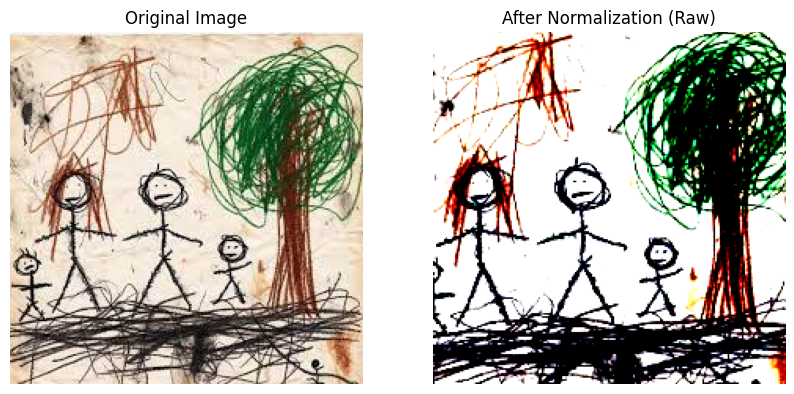

In [39]:
img_norm = transform(image)
fig, axs = plt.subplots(1, 2, figsize=(10,5))

# Original Imagw
axs[0].imshow(image)
axs[0].set_title("Original Image")
axs[0].axis("off")

# Normalized Image
axs[1].imshow(img_norm.permute(1,2,0))
axs[1].set_title("After Normalization (Raw)")
axs[1].axis("off")

plt.show()

**9. Run Both on the Test Image**

In [40]:
# ---------------------------------------------------
# PyTorch inference
# ---------------------------------------------------
with torch.no_grad():
    pytorch_output = model_PyTorch(input_tensor)
# ---------------------------------------------------
# ONNX inference
# ---------------------------------------------------
session = ort.InferenceSession("bouh_convnext_classifier_model.onnx")

onnx_output = session.run(
    None,
    {"image": input_tensor.numpy()}
)

**10. Map the Labels**

In [41]:
# ---------------------------------------------------
# class mapping used during training
# ---------------------------------------------------

CLASSES = [
    "سعادة",
    "حزن",
    "غضب",
    "خوف",
    "توتر وقلق"
]

# label → index
class_to_idx = {c: i for i, c in enumerate(CLASSES)}

# index → label
idx_to_class = {i: c for c, i in class_to_idx.items()}

print(idx_to_class)

{0: 'سعادة', 1: 'حزن', 2: 'غضب', 3: 'خوف', 4: 'توتر وقلق'}


**11. Verify Correct Conversion**

In [42]:
# verify correct format transformation

# convert logits → probabilities
pytorch_probs = F.softmax(pytorch_output, dim=1).numpy()

# fix ONNX tensor shape
onnx_logits = onnx_output[0]
onnx_probs = F.softmax(torch.tensor(onnx_logits), dim=1).numpy()

# predicted classes
pytorch_pred = np.argmax(pytorch_probs)
onnx_pred = np.argmax(onnx_probs)

print("PyTorch prediction index:", pytorch_pred)
print("ONNX prediction index:", onnx_pred)

print("PyTorch class:", idx_to_class[pytorch_pred])
print("ONNX class:", idx_to_class[onnx_pred])

print("\nClass probabilities:")
print("--------------------")

for i in range(len(idx_to_class)):
    print(
        "Index:", i,
        "| Class:", idx_to_class[i],
        "| PyTorch:", round(float(pytorch_probs[0][i]),4),
        "| ONNX:", round(float(onnx_probs[0][i]),4)
    )

PyTorch prediction index: 3
ONNX prediction index: 3
PyTorch class: خوف
ONNX class: خوف

Class probabilities:
--------------------
Index: 0 | Class: سعادة | PyTorch: 0.0042 | ONNX: 0.0042
Index: 1 | Class: حزن | PyTorch: 0.0376 | ONNX: 0.0376
Index: 2 | Class: غضب | PyTorch: 0.1185 | ONNX: 0.1185
Index: 3 | Class: خوف | PyTorch: 0.8393 | ONNX: 0.8393
Index: 4 | Class: توتر وقلق | PyTorch: 0.0003 | ONNX: 0.0003


**12. Verify Correct Conversion - All Logits**

In [43]:
# convert tensors to numpy
pytorch_logits = pytorch_output.numpy()
onnx_logits = onnx_output[0]

# compute difference
delta = pytorch_logits - onnx_logits

print("PyTorch logits:", pytorch_logits)
print("ONNX logits:", onnx_logits)

print("\nDelta (PyTorch - ONNX):")
print(delta)

# format number instead of scientific notation
max_diff = np.max(np.abs(delta))
print(f"\nMax absolute difference: {max_diff:.6f}")

PyTorch logits: [[-2.0512223   0.12989458  1.2784601   3.2357805  -4.5468764 ]]
ONNX logits: [[-2.0512233   0.12989613  1.2784578   3.2357826  -4.5468755 ]]

Delta (PyTorch - ONNX):
[[ 9.5367432e-07 -1.5497208e-06  2.3841858e-06 -2.1457672e-06
  -9.5367432e-07]]

Max absolute difference: 0.000002
